In [1]:
from pathlib import Path
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print('Device:', DEVICE)

Device: mps


In [3]:
BATCH_SIZE = 64
SEQ_LEN = 100
STRIDE = SEQ_LEN          # non-overlapping training windows

EMBED_SIZE = 128
HIDDEN_SIZE = 256
NUM_LAYERS = 2
DROPOUT = 0.2             # applied between LSTM layers

LEARNING_RATE = 0.002
EPOCHS = 20

TEMPERATURE = 0.8

torch.manual_seed(42)

In [4]:
URL = (
    "https://raw.githubusercontent.com/"
    "karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
)

DATA_PATH = Path("tinyshakespeare.txt")

if not DATA_PATH.exists():
    print("Downloading dataset...")
    response = requests.get(URL, timeout=30)
    response.raise_for_status()
    DATA_PATH.write_text(response.text, encoding="utf-8")

text = DATA_PATH.read_text(encoding="utf-8")

print("Number of characters:", len(text))

Number of characters: 1115394


In [5]:
print(text[:300])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [6]:
chars = sorted(set(text))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

print("Vocabulary size:", vocab_size)
print("Characters:", "".join(chars))

Vocabulary size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [7]:
def encode(s):
    return [stoi[c] for c in s]

def decode(indices):
    return "".join(itos[i] for i in indices)

print(encode('ROMEO:'))
print(decode(encode('ROMEO:')))

[30, 27, 25, 17, 27, 10]
ROMEO:


In [8]:
data = torch.tensor(encode(text), dtype=torch.long)

split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

print("Encoded data shape:", tuple(data.shape))
print("Train characters:", len(train_data))
print("Validation characters:", len(val_data))

Encoded data shape: (1115394,)
Train characters: 1003854
Validation characters: 111540


In [9]:
class CharDataset(Dataset):

    def __init__(self, data, seq_len, stride):
        self.data = data
        self.seq_len = seq_len
        self.stride = stride
        self.n_samples = (len(data) - seq_len - 1) // stride + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        start = idx * self.stride
        x = self.data[start:start + self.seq_len]
        y = self.data[start + 1:start + self.seq_len + 1]
        return x, y

In [10]:
train_dataset = CharDataset(train_data, SEQ_LEN, STRIDE)
val_dataset = CharDataset(val_data, SEQ_LEN, STRIDE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 156
Validation batches: 17


In [11]:
x_batch, y_batch = next(iter(train_loader))

print("x:", tuple(x_batch.shape))
print("y:", tuple(y_batch.shape))
print("\ninput :", repr(decode(x_batch[0, :40].tolist())))
print("target:", repr(decode(y_batch[0, :40].tolist())))

x: (64, 100)
y: (64, 100)

input : ' the demigod Authority\nMake us pay down '
target: 'the demigod Authority\nMake us pay down f'


In [12]:
class CharLSTM(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)

        # LSTM keeps two states: hidden h and cell c.
        # The cell state is the "conveyor belt" that carries information
        # across long distances, guarded by the forget / input / output gates.
        self.lstm = nn.LSTM(
            input_size = embed_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden = None):
        x = self.embedding(x)
        output, hidden = self.lstm(x, hidden)   # hidden = (h_n, c_n)
        output = self.dropout(output)
        logits = self.fc(output)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return h0, c0

In [13]:
model = CharLSTM(
    vocab_size = vocab_size,
    embed_size = EMBED_SIZE,
    hidden_size = HIDDEN_SIZE,
    num_layers = NUM_LAYERS,
    dropout = DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())

print(model)

print(total_params)

CharLSTM(
  (embedding): Embedding(65, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=65, bias=True)
)
946625


In [14]:
# an LSTM returns a tuple of states instead of a single hidden tensor
with torch.no_grad():
    logits, (h_n, c_n) = model(x_batch[:4].to(DEVICE))

print("logits :", tuple(logits.shape))         # [batch, seq_len, vocab_size]
print("hidden :", tuple(h_n.shape))            # [num_layers, batch, hidden_size]
print("cell   :", tuple(c_n.shape))            # [num_layers, batch, hidden_size]

logits : (4, 100, 65)
hidden : (2, 4, 256)
cell   : (2, 4, 256)


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

In [16]:
def train_one_epoch():
    model.train()
    total_loss = 0.0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()

        # gates keep gradients much healthier than a vanilla RNN,
        # but clipping is still cheap insurance
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [17]:
@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0.0

    for x, y in val_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits, _ = model(x)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        total_loss += loss.item()

    return total_loss / len(val_loader)

In [18]:
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    val_loss = evaluate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

Epoch [01/20] | Train Loss: 2.2213 | Val Loss: 1.8773
Epoch [02/20] | Train Loss: 1.7116 | Val Loss: 1.7405
Epoch [03/20] | Train Loss: 1.5930 | Val Loss: 1.6737
Epoch [04/20] | Train Loss: 1.5345 | Val Loss: 1.6402
Epoch [05/20] | Train Loss: 1.4978 | Val Loss: 1.6185
Epoch [06/20] | Train Loss: 1.4744 | Val Loss: 1.6074
Epoch [07/20] | Train Loss: 1.4553 | Val Loss: 1.6003
Epoch [08/20] | Train Loss: 1.4404 | Val Loss: 1.5891
Epoch [09/20] | Train Loss: 1.4284 | Val Loss: 1.5835
Epoch [10/20] | Train Loss: 1.4173 | Val Loss: 1.5778
Epoch [11/20] | Train Loss: 1.4095 | Val Loss: 1.5762
Epoch [12/20] | Train Loss: 1.4014 | Val Loss: 1.5736
Epoch [13/20] | Train Loss: 1.3953 | Val Loss: 1.5675
Epoch [14/20] | Train Loss: 1.3894 | Val Loss: 1.5651
Epoch [15/20] | Train Loss: 1.3840 | Val Loss: 1.5639
Epoch [16/20] | Train Loss: 1.3789 | Val Loss: 1.5667
Epoch [17/20] | Train Loss: 1.3757 | Val Loss: 1.5689
Epoch [18/20] | Train Loss: 1.3730 | Val Loss: 1.5608
Epoch [19/20] | Train Loss: 

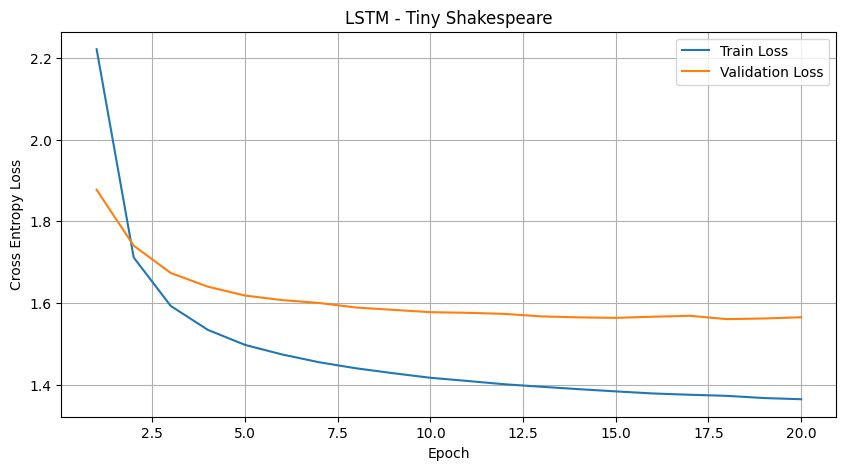

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("LSTM - Tiny Shakespeare")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
@torch.no_grad()
def generate_text(prompt, max_new_tokens=500, temperature=0.8):
    model.eval()

    input_ids = torch.tensor(
        encode(prompt), dtype=torch.long, device=DEVICE
    ).unsqueeze(0)   # [1, seq_len]

    hidden = model.init_hidden(batch_size=1, device=DEVICE)

    # warm the states up on the prompt, then feed one character at a time
    if input_ids.shape[1] > 1:
        _, hidden = model(input_ids[:, :-1], hidden)

    current = input_ids[:, -1:]
    generated = prompt

    for _ in range(max_new_tokens):
        logits, hidden = model(current, hidden)

        logits = logits[:, -1, :] / temperature
        probabilities = F.softmax(logits, dim=-1)

        next_char = torch.multinomial(probabilities, num_samples=1)

        generated += itos[next_char.item()]
        current = next_char

    return generated

In [21]:
print(generate_text("Hello", max_new_tokens=200, temperature=TEMPERATURE))

Hellow to mysily by tongue shall not, without the encounten, who dost she,
then of that stands went and his fortune;
Come tony and underceit to have the queen, seeing and power.
Doth grow many?--'posent, s


In [22]:
for temp in [0.5, 0.8, 1.2]:
    print(f"--- temperature = {temp} ---")
    print(generate_text("ROMEO:", max_new_tokens=200, temperature=temp))
    print()

--- temperature = 0.5 ---
ROMEO:
Why hence a mercy that I do marry him?

MENENIUS:
My lord, and may not live and hearten,
Who shall see the cheer his good put of injuration,
And then the common come to death of the change and fortun

--- temperature = 0.8 ---
ROMEO:
But, for that hang, sent, they can.
Romeo! and in a man, by the hublity and but ay a iffereral?
The desirisain the like to be for'cut by the bower, good uncle.
Most warliang and his mawful perportion

--- temperature = 1.2 ---
ROMEO:
Beautais of Balamerbies! what isress'd she, but postiblal
And were Tanuileates.
Chan may, pray his demaverupoo? you. Hereford there to thy arm, asford hair matter wend me.
Strange, be Gander. Sear! g



In [ ]:
checkpoint_path = "lstm_shakespeare.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "stoi": stoi,
        "itos": itos,
        "vocab_size": vocab_size,
        "embed_size": EMBED_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
    },
    checkpoint_path,
)

print("Model saved to:", checkpoint_path)